# Figures of Appendix C

In [1]:
# figure settings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import proj3d

phase_size = (8, 4)
sphere_size = (8, 4)
basis_size = (7, 4)
dpi = 196
label = 13
subtitle = 11
line_width = 1.5
plt.rcParams.update({
    "text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
    "text.latex.preamble": r"\usepackage{braket}",
    "axes.titlesize": 13, "axes.labelsize": label, "xtick.labelsize": 11,
    "ytick.labelsize": 11, "legend.fontsize": 11, "figure.facecolor": "white",
    "lines.linewidth": line_width, "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round", "lines.solid_joinstyle": "round",
    "lines.dash_joinstyle": "round", "pdf.fonttype": 42,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})
blue, teal, orange, violet = "#1478E1", "#19A0A0", "#FA8200", "#8C64E1"
grey, dark_grey = "#787878", "#3C3C3C"
tab = dict(boxstyle="round", facecolor="white", alpha=.9,
           edgecolor=plt.rcParams["legend.edgecolor"])
arrow = dict(arrowstyle="-|>", lw=line_width, mutation_scale=11, shrinkA=0, shrinkB=0)

# Filled arrows projected from the fixed 3D view.
def arrow3d(ax, start, end, color, zorder=8):
    x, y, _ = proj3d.proj_transform(*np.array([start, end]).T, ax.get_proj())
    ax.annotate("", (x[1], y[1]), (x[0], y[0]), zorder=zorder,
                arrowprops=dict(arrow, color=color))

output_directory = Path("figures_topo") if Path("figures_topo").is_dir() else Path(".")


## C.1 Phase choices on a closed path

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


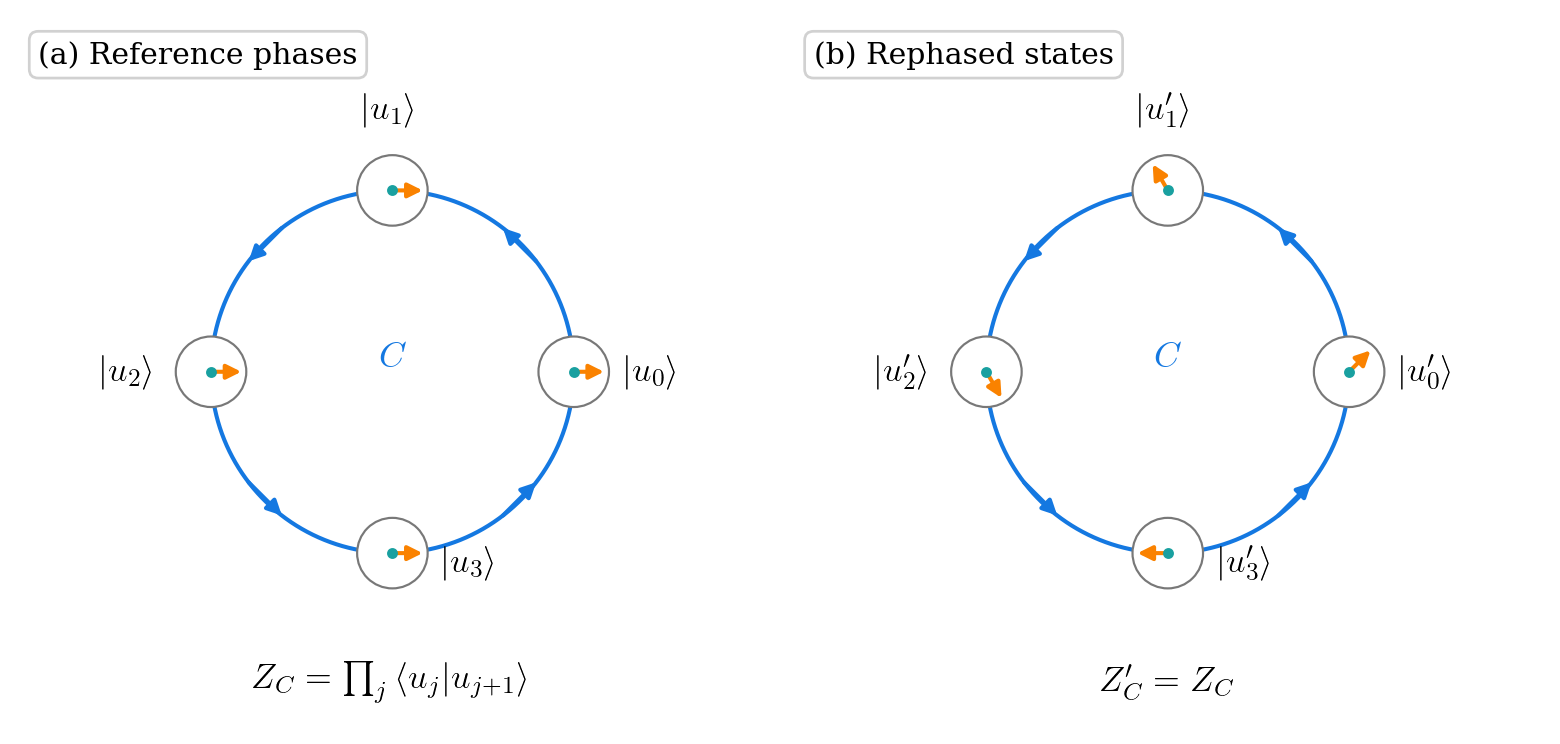

In [2]:
# local phase choices on the same four-point loop
angles = np.arange(4)*np.pi/2
points = .72*np.column_stack((np.cos(angles), np.sin(angles)))
gauges = [np.zeros(4), np.array([np.pi/4, 2*np.pi/3, -np.pi/3, np.pi])]
titles = ["(a) Reference phases", "(b) Rephased states"]
fig, axes = plt.subplots(1, 2, figsize=phase_size, dpi=dpi)
fig.subplots_adjust(left=.015, right=.985, bottom=.02, top=.99, wspace=.04)

for panel, (ax, phases) in enumerate(zip(axes, gauges)):
    ax.set(aspect="equal", xlim=(-1.48, 1.48), ylim=(-1.4, 1.4))
    ax.axis("off")
    ax.set_title(titles[panel], loc="left", x=.025, y=.97, pad=0,
                 va="top", fontsize=subtitle, bbox=tab)
    t = np.linspace(0, 2*np.pi, 361)
    ax.plot(.72*np.cos(t), .72*np.sin(t), color=blue)
    for a in angles + np.pi/4:
        start = .72*np.array([np.cos(a-.13), np.sin(a-.13)])
        end = .72*np.array([np.cos(a+.13), np.sin(a+.13)])
        ax.annotate("", end, start, arrowprops=dict(arrow, color=blue))
    for j, (point, phase) in enumerate(zip(points, phases)):
        ax.add_patch(Circle(point, .14, facecolor="white", edgecolor=grey,
                            lw=.8, zorder=4))
        end = point + .12*np.array([np.cos(phase), np.sin(phase)])
        ax.annotate("", end, point, zorder=6, arrowprops=dict(arrow, color=orange))
        ax.plot(*point, marker="o", ms=3, color=teal, zorder=7)
        position = point + .32*np.array([np.cos(angles[j]), np.sin(angles[j])])
        if j == 3:
            position = point + [.32, -.04]
        name = rf"$\ket{{u_{j}}}$" if panel == 0 else rf"$\ket{{u'_{j}}}$"
        ax.text(*position, name, fontsize=label, ha="center", va="center", usetex=True)
    ax.text(0, .02, r"$C$", fontsize=label, color=blue, ha="center")
    formula = (r"$Z_C=\prod_j\braket{u_j|u_{j+1}}$" if panel == 0
               else r"$Z'_C=Z_C$")
    ax.text(0, -1.23, formula, fontsize=label, ha="center", va="center", usetex=True)

fig.savefig(output_directory / "C.1_phase_gauge.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)


## C.2 Geometric phase of a two-component state

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


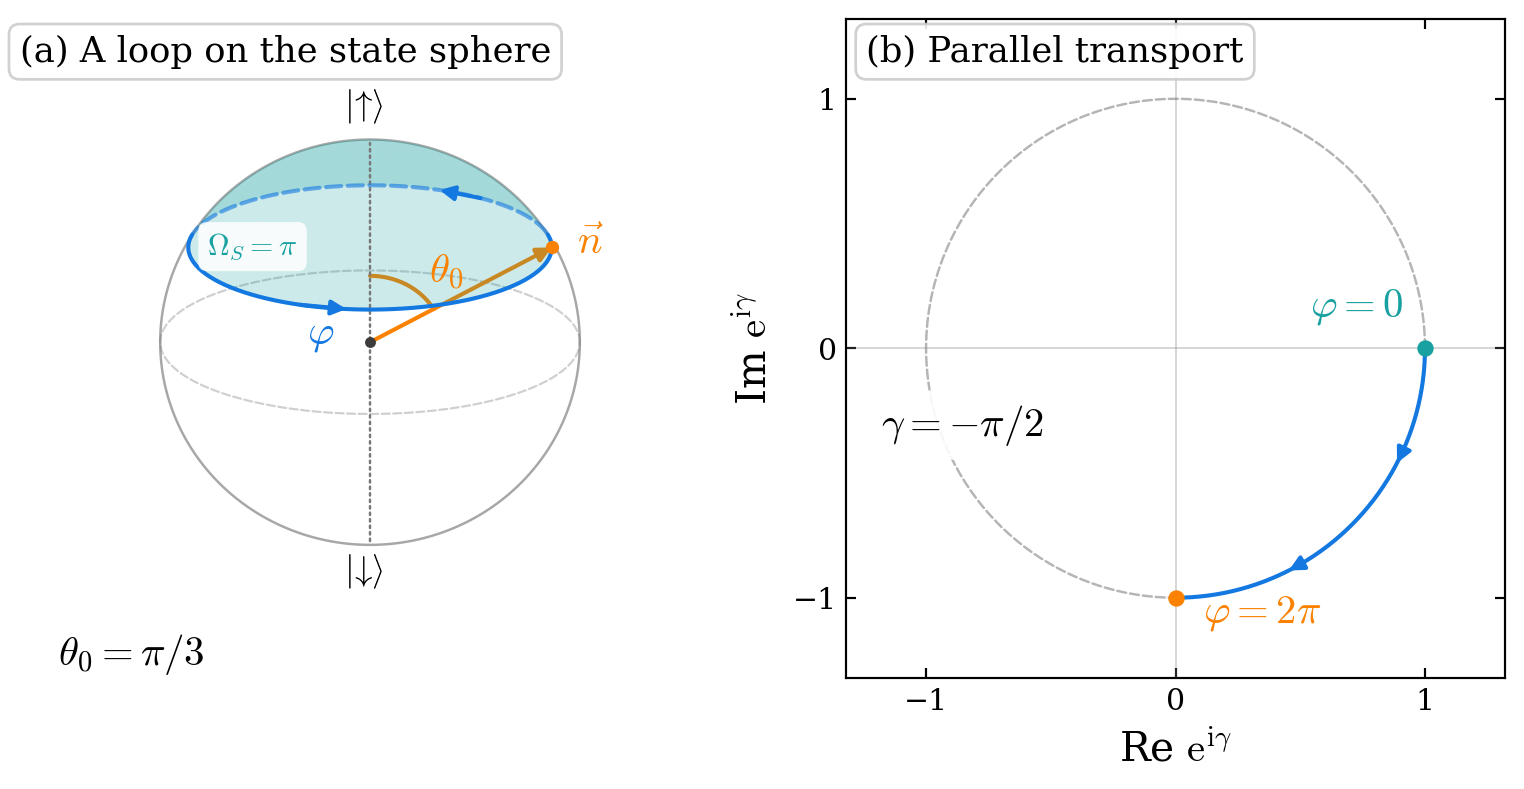

In [3]:
# exact two-component example: theta_0 = pi/3
# The right panel shows a complex phase factor, not a spin direction.
theta0 = np.pi/3
phi = np.linspace(0, 2*np.pi, 241)
gamma = -phi*np.sin(theta0/2)**2
phase_factor = np.exp(1j*gamma)
fig = plt.figure(figsize=sphere_size, dpi=dpi)
gs = fig.add_gridspec(1, 2, left=.01, right=.985, bottom=.13, top=.97, wspace=.14)
ax = fig.add_subplot(gs[0, 0], projection="3d", computed_zorder=False)
ax.set_proj_type("ortho")
ax.view_init(elev=20, azim=-90)
ax.set_box_aspect((1, 1, 1), zoom=1.2)
ax.set(xlim=(-1.12, 1.12), ylim=(-1.12, 1.12), zlim=(-1.15, 1.18))
ax.set_axis_off()
fig.text(.02, .95, "(a) A loop on the state sphere",
         fontsize=13, ha="left", va="top", bbox=tab)

# sphere outline, equator and northern cap
view_angle = np.deg2rad(ax.elev)
outline = np.column_stack((np.cos(phi), np.sin(view_angle)*np.sin(phi),
                           np.cos(view_angle)*np.sin(phi)))
ax.plot(*outline.T, color=grey, alpha=.65, lw=.9, zorder=1)
ax.plot(np.cos(phi), np.sin(phi), np.zeros_like(phi),
        color=grey, ls="--", alpha=.35, lw=.8, zorder=1)
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 61), np.linspace(0, theta0, 16))
ax.plot_surface(np.sin(v)*np.cos(u), np.sin(v)*np.sin(u), np.cos(v),
                color=teal, alpha=.22, shade=False, linewidth=0, zorder=2)
loop = np.column_stack((np.sin(theta0)*np.cos(phi),
                        np.sin(theta0)*np.sin(phi), np.full_like(phi, np.cos(theta0))))
front = loop @ np.array([0, -np.cos(view_angle), np.sin(view_angle)]) >= 0
ax.plot(*np.where(front[:, None], np.nan, loop).T,
        color=blue, ls="--", alpha=.6, zorder=4)
ax.plot(*np.where(front[:, None], loop, np.nan).T, color=blue, zorder=4)
for j in (35, 165):
    arrow3d(ax, loop[j], loop[j+10], blue)
ax.text(-.30, -.78, .45, r"$\varphi$", fontsize=15, color=blue, va="top")

# the common origin of the polar axis and state vector
point = loop[0]
ax.plot([0, 0], [0, 0], [-1.05, 1.05], color=grey, ls=":", lw=.9, zorder=3)
ax.scatter(0, 0, 0, color=dark_grey, s=9, depthshade=False, zorder=7)
arrow3d(ax, [0, 0, 0], point, orange, zorder=1.5)
ax.scatter(*point, color=orange, s=15, depthshade=False, zorder=9)
a = np.linspace(0, theta0, 60)
ax.plot(.35*np.sin(a), np.zeros_like(a), .35*np.cos(a), color=orange, zorder=1.5)
ax.text(.28, -.03, .33, r"$\theta_0$", fontsize=15, color=orange, zorder=7)
ax.text(*(point + [.12, 0, -.03]), r"$\vec{n}$", fontsize=15, color=orange)
ax.text(0, 0, 1.2, r"$\ket{\uparrow}$", fontsize=label, ha="center", usetex=True)
ax.text(0, 0, -1.25, r"$\ket{\downarrow}$", fontsize=label, ha="center", usetex=True)
ax.text(-.56, -.2, .58, r"$\Omega_S=\mathrm{\pi}$", fontsize=11, color=teal,
        ha="center", va="center", zorder=8,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.85))
ax.text2D(.04, .02, r"$\theta_0=\mathrm{\pi}/3$", transform=ax.transAxes,
          fontsize=15, bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.9))

# the phase accumulated by parallel transport
ax = fig.add_subplot(gs[0, 1])
ax.set(aspect="equal", xlim=(-1.32, 1.32), ylim=(-1.32, 1.32),
       xticks=[-1, 0, 1], yticks=[-1, 0, 1])
ax.set_xlabel(r"Re $\mathrm{e}^{\mathrm{i}\gamma}$", fontsize=15, labelpad=5)
ax.set_ylabel(r"Im $\mathrm{e}^{\mathrm{i}\gamma}$", fontsize=15, labelpad=6)
fig.text(.56, .95, "(b) Parallel transport",
         fontsize=13, ha="left", va="top", bbox=tab)
ax.plot(np.cos(phi), np.sin(phi), color=grey, ls="--", lw=.9, alpha=.55)
ax.axhline(0, color=grey, lw=.7, alpha=.3)
ax.axvline(0, color=grey, lw=.7, alpha=.3)
ax.plot(phase_factor.real, phase_factor.imag, color=blue)
for j in (65, 160):
    ax.annotate("", (phase_factor[j+8].real, phase_factor[j+8].imag),
                (phase_factor[j].real, phase_factor[j].imag),
                arrowprops=dict(arrow, color=blue))
ax.plot([1], [0], "o", color=teal, ms=5)
ax.plot([0], [-1], "o", color=orange, ms=5)
ax.annotate(r"$\varphi=0$", (1, 0), xytext=(-8, 12), textcoords="offset points",
            ha="right", fontsize=15, color=teal)
ax.annotate(r"$\varphi=2\mathrm{\pi}$", (0, -1), xytext=(10, -9), textcoords="offset points",
            fontsize=15, color=orange)
ax.text(-1.18, -.35, r"$\gamma=-\mathrm{\pi}/2$", fontsize=15,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.9))

fig.savefig(output_directory / "C.2_geometric_phase.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)


## C.3 A fixed subspace and two bases

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


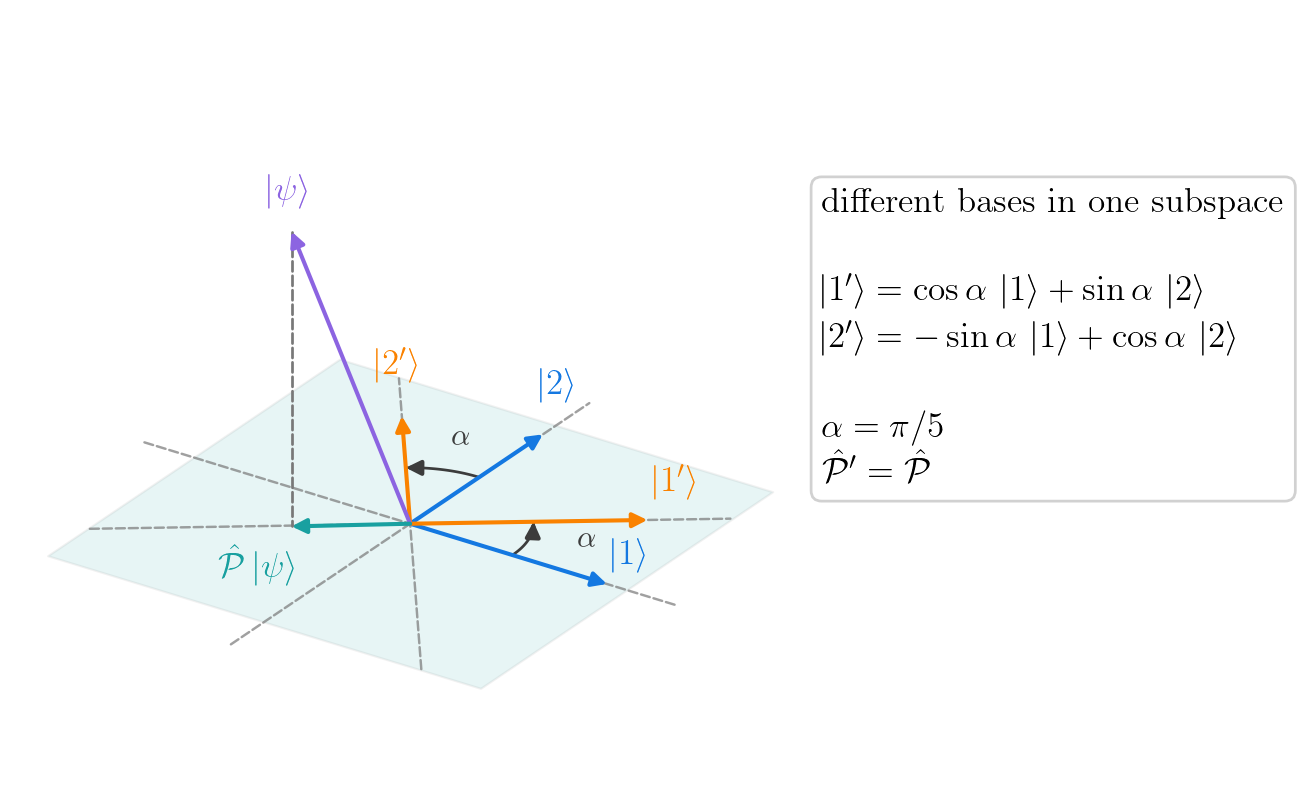

In [5]:
# a real rotation is a simple unitary change of basis
angle = np.pi/5
axis_extent = 1.35
basis = np.array([[1., 0., 0.], [0., 1., 0.]])
rotated = np.array([[np.cos(angle), np.sin(angle), 0.],
                    [-np.sin(angle), np.cos(angle), 0.]])
psi = np.array([-.40, -.30, .82])
projection = np.array([psi[0], psi[1], 0.])
fig = plt.figure(figsize=basis_size, dpi=dpi)
ax = fig.add_axes([.01, .015, .565, .97], projection="3d", computed_zorder=False)
ax.set_proj_type("ortho")
ax.view_init(elev=27, azim=-56)
ax.set_box_aspect((1, 1, .85), zoom=1.25)
ax.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), zlim=(-.25, 1.0))
ax.set_axis_off()
plane = [[-1.1, -1.1, 0], [1.1, -1.1, 0], [1.1, 1.1, 0], [-1.1, 1.1, 0]]
ax.add_collection3d(Poly3DCollection([plane], facecolor=teal, alpha=.10,
                                   edgecolor=grey, linewidth=.8, zorder=1))
for vectors, color, prime in [(basis, blue, ""), (rotated, orange, "'")]:
    for j, vector in enumerate(vectors):
        axis = np.outer([-axis_extent, axis_extent], vector)
        ax.plot(*axis.T, color=grey, ls="--", lw=.9, alpha=.7, zorder=3)
        arrow3d(ax, [0, 0, 0], vector, color)
        position = 1.13*vector + [0, 0, .08]
        ax.text(*position, rf"$\ket{{{j+1}{prime}}}$", color=color,
                fontsize=label, ha="center", zorder=6, usetex=True)
# The same rotation relates both pairs of basis vectors.
a = np.linspace(0, angle, 41)
for offset in (0, np.pi/2):
    arc = .52*np.column_stack((np.cos(a+offset), np.sin(a+offset), np.zeros_like(a)))
    ax.plot(*arc.T, color=dark_grey, lw=1, zorder=7)
    arrow3d(ax, arc[-8], arc[-1], dark_grey)
    position = .77*np.array([np.cos(offset+angle/2), np.sin(offset+angle/2), 0])
    ax.text(*position, r"$\alpha$", fontsize=11, color=dark_grey, ha="center", zorder=9)
arrow3d(ax, [0, 0, 0], psi, violet)
arrow3d(ax, [0, 0, 0], projection, teal)
ax.plot([psi[0], projection[0]], [psi[1], projection[1]], [psi[2], 0],
        color=grey, ls="--", lw=1, zorder=3)
ax.text(*(psi + [0, 0, .09]), r"$\ket{\psi}$", color=violet, fontsize=label, ha="center", usetex=True)
ax.text(*(projection + [-.10, -.10, -.13]), r"$\hat{\mathcal{P}}\ket{\psi}$",
        color=teal, fontsize=label, ha="center", zorder=7, usetex=True)
info = ("different bases in one subspace\n\n"
        r"$\ket{1'}=\cos\alpha\,\ket{1}+\sin\alpha\,\ket{2}$" + "\n"
        r"$\ket{2'}=-\sin\alpha\,\ket{1}+\cos\alpha\,\ket{2}$" + "\n\n"
        r"$\alpha=\mathrm{\pi}/5$" + "\n"
        r"$\hat{\mathcal{P}}'=\hat{\mathcal{P}}$")
fig.text(.60, .77, info, fontsize=label, ha="left", va="top",
         linespacing=1.45, bbox=tab, usetex=True)

fig.savefig(output_directory / "C.3_subspace_basis.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)
